In [107]:
import os
import sys

sys.path.append("..")
import torch

In [108]:
with open("../writing/saveZincLog/exp_9/output_log.txt") as f:
    lines = f.readlines()

flag = False
layer0_result_dicts = {
    "Epoch": [],
    "num_neurons_layer_0": [],
    "dup_neurons_layer_0": [],
    "del_neurons_layer_0": [],
}
for line in lines:
    if line.split(":")[0] == "Epoch":
        if flag == False:
            layer0_result_dicts["Epoch"].append(int(line.split(":")[1]))
            flag = True
        else:
            flag = False
    elif line.split(":")[0] == "num_neurons_layer_0":
        layer0_result_dicts["num_neurons_layer_0"].append(
            int(line.split(":")[1].split("(")[1][:-2])
        )
    elif line.split(":")[0] == "dup_neurons_layer_0":
        layer0_result_dicts["dup_neurons_layer_0"].append(
            int(float(line.split(":")[1][:-1]))
        )
    elif line.split(":")[0] == "del_neurons_layer_0":
        layer0_result_dicts["del_neurons_layer_0"].append(
            int(float(line.split(":")[1][:-1]))
        )
    else:
        continue

/tmp/ipykernel_77763/2242775872.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20c')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


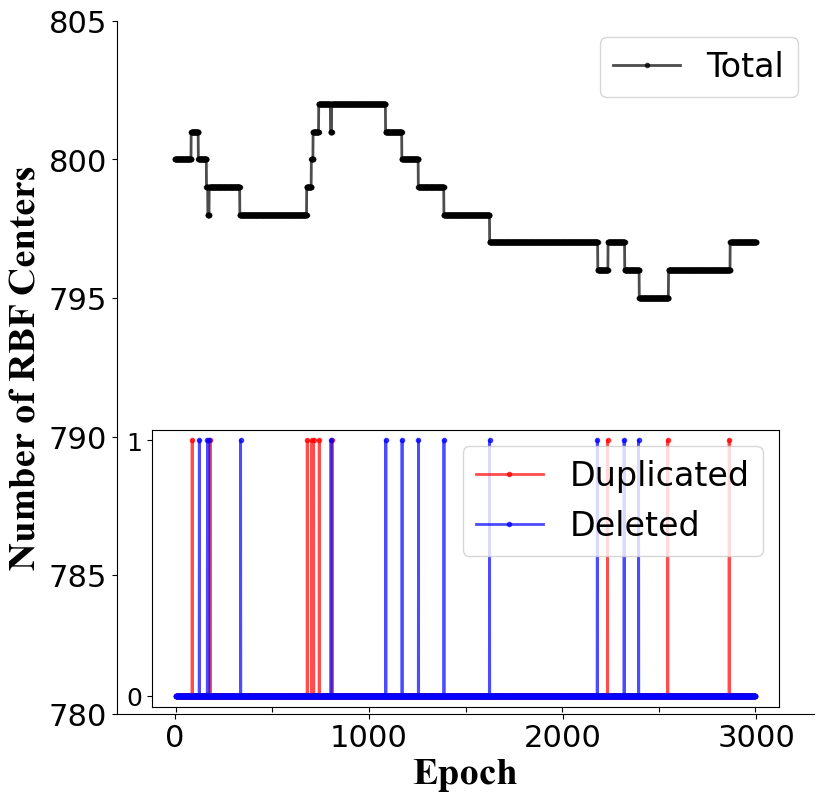

In [109]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 1, figsize=(9,9))

cmap = plt.cm.get_cmap('tab20c')
colors = cmap(np.linspace(0, 1, 3))

ax.margins(x=0.1, y=0.1)
ax.set_xlabel('Epoch', fontdict={"family": "Times New Roman","weight": "bold", "size": 28})
ax.set_ylabel('Number of RBF Centers', fontdict={"family": "Times New Roman","weight": "bold", "size": 28})
ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(780, 805)
ax.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["num_neurons_layer_0"], marker='.', color="k", alpha=0.7, linewidth=2, linestyle='-')

# ax.grid(ls="-.", lw=0.5, c="grey")
ax.legend()

axins1 = inset_axes(ax, width="90%", height="40%", loc='upper left', bbox_to_anchor=(0.04, -0.58, 1, 1), bbox_transform=ax.transAxes)
axins1.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["dup_neurons_layer_0"], marker='.', color="r", alpha=0.7, linewidth=2, linestyle='-')
axins1.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["del_neurons_layer_0"], marker='.', color="b", alpha=0.7, linewidth=2, linestyle='-')

# axins1.set_ylim(-0.5, 12)
axins1.tick_params(axis='x', labelsize=18)
axins1.set_xticklabels([])
axins1.tick_params(axis='y', labelsize=18)
axins1.yaxis.set_major_locator(MaxNLocator(integer=True))
# axins1.grid(ls="-.", lw=0.5, c="grey")
axins1.margins(x=0.042, y=0.042)

ax.legend(["Total"], prop={'size':24})
axins1.legend([ "Duplicated", "Deleted"], prop={'size':24})
plt.savefig('Zinc_Neuron_Adj.svg', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

In [110]:
from model import FF_TE
from config import config

train_set = FF_TE.FF_ZINC("train")
val_set = FF_TE.FF_ZINC("val")
test_set = FF_TE.FF_ZINC("test")
trn_loader = torch.utils.data.DataLoader(
    train_set,
    config.batch_size,
    drop_last=False,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    config.batch_size,
    drop_last=True,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
tst_loader = torch.utils.data.DataLoader(
    test_set,
    config.batch_size,
    drop_last=False,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

In [111]:
import torch
from model import FF_RBF, utils

model = torch.load("../writing/saveZincLog/exp_6/output_model.pth").to(
    torch.device(config.device)
)
with torch.no_grad():
    output = []
    pos_embeddings = []
    neg_embeddings = []
    target = []
    for inputs, labels in tst_loader:
        inputs, labels = utils.preprocess_inputs(inputs, labels)

        pos_z, neg_z = model.embedding(inputs)
        pos_embeddings.append(pos_z)
        neg_embeddings.append(neg_z)
        scarlar_output = model.forward_downstream_classification_model(inputs, labels)
        output.append(scarlar_output["output"].detach().argmax(dim=1, keepdim=False))
        target.append(labels["class_labels"].detach())
    output = torch.concat(output, dim=0)
    pos_embeddings = torch.cat(pos_embeddings, dim=0)
    neg_embeddings = torch.cat(neg_embeddings, dim=0)
    target = torch.concat(target, dim=0)

    print(output.shape, target.shape)

/ExtHDD/Users/Astroyd/SORBF/writing/../model/FF_TE.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(class_label), num_classes=self.num_classes
/ExtHDD/Users/Astroyd/SORBF/writing/../model/FF_TE.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(class_label), num_classes=self.num_classes
/ExtHDD/Users/Astroyd/SORBF/writing/../model/FF_TE.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(class_label), num_classes=self.num_classes


torch.Size([451]) torch.Size([451])


In [112]:
embeddings = torch.concat([pos_embeddings, neg_embeddings], dim=0).cpu().numpy()
labels = np.ones(embeddings.shape[0])
labels[: neg_embeddings.shape[0]] = 0


from sklearn.manifold import TSNE

X_embedded = TSNE(
    n_components=2,
    learning_rate=1000,
    perplexity=30,
    max_iter=2000,
    early_exaggeration=7,
).fit_transform(pos_embeddings.cpu().numpy())
X_norm_pos = (X_embedded - X_embedded.min(0)) / (X_embedded.max(0) - X_embedded.min(0))

X_embedded = TSNE(
    n_components=2,
    learning_rate=1000,
    perplexity=30,
    max_iter=2000,
    early_exaggeration=7,
).fit_transform(neg_embeddings.cpu().numpy())
X_norm_neg = (X_embedded - X_embedded.min(0)) / (X_embedded.max(0) - X_embedded.min(0))

/tmp/ipykernel_77763/398371300.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Dark2")
/tmp/ipykernel_77763/398371300.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_77763/398371300.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


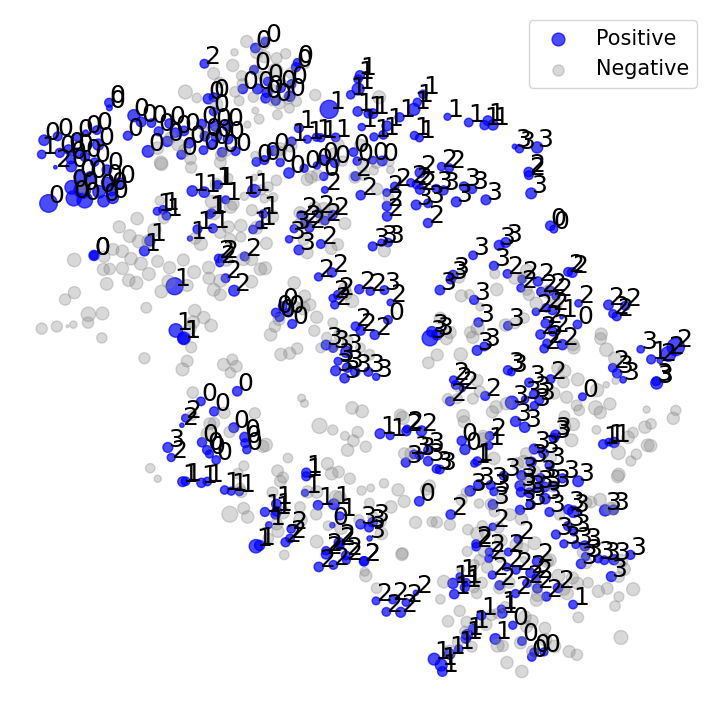

In [120]:
import matplotlib.patches as patches

cmap = plt.cm.get_cmap("Dark2")
colors = cmap(np.linspace(0, 1, 2))

sizes_pos = torch.sum(pos_embeddings**2, dim=1).cpu().numpy()
sizes_pos = (sizes_pos - np.amin(sizes_pos, axis=0)) / (
    np.amax(sizes_pos, axis=0) - np.amin(sizes_pos, axis=0)
)
sizes_neg = torch.sum(neg_embeddings**2, dim=1).cpu().numpy()
sizes_neg = (sizes_neg - np.amin(sizes_neg, axis=0)) / (
    np.amax(sizes_neg, axis=0) - np.amin(sizes_neg, axis=0)
)

plt.figure(figsize=(9, 9))
plt.scatter(
    X_norm_pos[:, 0],
    X_norm_pos[:, 1],
    c="b",
    alpha=0.7,
    s=sizes_pos * 170,
    label="Positive",
    cmap="Dark2",
)
plt.scatter(
    X_norm_neg[:, 0],
    X_norm_neg[:, 1],
    c="grey",
    alpha=0.3,
    s=sizes_neg * 130,
    label="Negative",
    cmap="Dark2",
)
plt.xticks([])
plt.yticks([])
for i in range(pos_embeddings.shape[0]):
    plt.text(
        X_norm_pos[i, 0],
        X_norm_pos[i, 1],
        str(target[i].item()),
        fontdict={"size": 18},
    )

# arc1 = patches.Arc((-0.3, 0.4), 1.2, 1.2, color="r", theta1=-40, theta2=25, lw=1.7)
# plt.gcf().gca().add_artist(arc1)

# arc2 = patches.Arc((0.52, 0.17), 0.47, 0.47, color="r", theta1=-10, theta2=230, lw=1.7)
# plt.gcf().gca().add_artist(arc2)

# arc3 = patches.Arc((1.2, 1.0), 1.3, 1.3, color="r", theta1=185, theta2=260, lw=1.7)
# plt.gcf().gca().add_artist(arc3)

# plt.text(0.05, 0.5, str(0), fontdict={"size": 24})
# plt.text(0.65, 0.05, str(1), fontdict={"size": 24})
# plt.text(0.32, 0.85, str(2), fontdict={"size": 24})
# plt.text(0.93, 0.72, str(3), fontdict={"size": 24})

for spine in plt.gcf().gca().spines.values():
    spine.set_visible(False)

plt.legend(prop={"size": 15})
plt.savefig("Zinc_ARBF_Embedding.svg", bbox_inches="tight", pad_inches=0, dpi=1200)